# 01. Raw Data Audit

RetailRocket E-commerce Dataset의 원천 데이터를 점검하는 노트북이다.  
이 단계의 목적은 분석을 시작하기 전에 데이터의 크기, 구조, 기간, 이벤트 분포, 결측치, 중복, 주요 키 연결성을 확인하는 것이다.

이 노트북의 산출물은 이후 분석 단계에서 그대로 사용한다.

- `02_event_funnel_analysis.ipynb`
- `03_item_category_analysis.ipynb`
- `04_ab_test_design_simulation.ipynb`
- `05_business_recommendation.ipynb`
- `app/streamlit_app.py`

## 0. Import Libraries

In [1]:
from pathlib import Path
import os
import gc
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Project Path Setting

VS Code/Jupyter에서 노트북을 `notebooks/` 폴더 안에서 실행해도, 프로젝트 루트에서 실행해도 동작하도록 경로를 자동 설정한다.

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [PROCESSED_DIR, OUTPUT_DIR, CHART_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

EVENTS_PATH = RAW_DIR / "events.csv"
ITEM_PROP_1_PATH = RAW_DIR / "item_properties_part1.csv"
ITEM_PROP_2_PATH = RAW_DIR / "item_properties_part2.csv"
CATEGORY_TREE_PATH = RAW_DIR / "category_tree.csv"

raw_files = [
    EVENTS_PATH,
    ITEM_PROP_1_PATH,
    ITEM_PROP_2_PATH,
    CATEGORY_TREE_PATH,
]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
for file in raw_files:
    print(file.name, "exists:", file.exists())

PROJECT_ROOT: c:\Users\USER\Desktop\ecommerce_ab_test_project
RAW_DIR: c:\Users\USER\Desktop\ecommerce_ab_test_project\data\raw
events.csv exists: True
item_properties_part1.csv exists: True
item_properties_part2.csv exists: True
category_tree.csv exists: True


## 2. Utility Functions

In [3]:
def format_bytes(size_bytes: int) -> str:
    """Return human-readable file size."""
    if size_bytes == 0:
        return "0B"
    units = ["B", "KB", "MB", "GB", "TB"]
    idx = int(np.floor(np.log(size_bytes) / np.log(1024)))
    idx = min(idx, len(units) - 1)
    value = size_bytes / (1024 ** idx)
    return f"{value:,.2f} {units[idx]}"


def count_csv_rows(path: Path) -> int:
    """Count rows in a CSV file excluding the header."""
    with open(path, "rb") as f:
        return max(sum(1 for _ in f) - 1, 0)


def basic_df_audit(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Create a column-level audit table for a loaded DataFrame."""
    audit = pd.DataFrame({
        "file": name,
        "column": df.columns,
        "dtype": [str(dtype) for dtype in df.dtypes],
        "non_null_count": df.notna().sum().values,
        "null_count": df.isna().sum().values,
        "null_rate": df.isna().mean().values,
        "unique_count": [df[col].nunique(dropna=True) for col in df.columns],
    })
    return audit


def save_table(df: pd.DataFrame, filename: str, index: bool = False) -> Path:
    """Save dataframe to outputs/tables and return path."""
    save_path = TABLE_DIR / filename
    df.to_csv(save_path, index=index, encoding="utf-8-sig")
    print(f"saved: {save_path}")
    return save_path


def save_parquet_or_csv(df: pd.DataFrame, parquet_name: str, csv_name: str) -> None:
    """Save as parquet if pyarrow is available. Also save CSV for compatibility."""
    csv_path = PROCESSED_DIR / csv_name
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")
    print(f"saved: {csv_path}")
    
    try:
        parquet_path = PROCESSED_DIR / parquet_name
        df.to_parquet(parquet_path, index=False)
        print(f"saved: {parquet_path}")
    except Exception as e:
        print("parquet save skipped:", e)

## 3. File Inventory

원천 데이터 파일의 존재 여부, 파일 크기, 행 수를 확인한다.  
이 결과는 README의 Raw Data Summary에도 활용할 수 있다.

In [4]:
file_inventory = []

for path in raw_files:
    if path.exists():
        size_bytes = path.stat().st_size
        row_count = count_csv_rows(path)
        file_inventory.append({
            "file": path.name,
            "exists": True,
            "size_bytes": size_bytes,
            "size_readable": format_bytes(size_bytes),
            "row_count": row_count,
        })
    else:
        file_inventory.append({
            "file": path.name,
            "exists": False,
            "size_bytes": None,
            "size_readable": None,
            "row_count": None,
        })

file_inventory_df = pd.DataFrame(file_inventory)
display(file_inventory_df)
save_table(file_inventory_df, "01_file_inventory.csv")

,file,exists,size_bytes,size_readable,row_count
0,events.csv,True,94237913,89.87 MB,2756101
1,item_properties_part1.csv,True,484315749,461.88 MB,10999999
2,item_properties_part2.csv,True,408929907,389.99 MB,9275903
3,category_tree.csv,True,14454,14.12 KB,1669


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_file_inventory.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_file_inventory.csv')

## 4. Load `events.csv`

`events.csv`는 이 프로젝트의 핵심 행동 로그 파일이다.  
사용자 행동은 `view`, `addtocart`, `transaction`으로 구성된다.

In [5]:
events_dtype = {
    "timestamp": "int64",
    "visitorid": "int64",
    "event": "category",
    "itemid": "int64",
    "transactionid": "float64",
}

events = pd.read_csv(EVENTS_PATH, dtype=events_dtype)

events["event_time"] = pd.to_datetime(events["timestamp"], unit="ms")
events["event_date"] = events["event_time"].dt.date
events["event_month"] = events["event_time"].dt.to_period("M").astype(str)

print("events shape:", events.shape)
display(events.head())
display(events.tail())

events shape: (2756101, 8)


,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_month
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,2015-06
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,2015-06
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,2015-06
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,2015-06
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,2015-06


,timestamp,visitorid,event,itemid,transactionid,event_time,event_date,event_month
2756096,1438398785939,591435,view,261427,NaN,2015-08-01 03:13:05.939,2015-08-01,2015-08
2756097,1438399813142,762376,view,115946,NaN,2015-08-01 03:30:13.142,2015-08-01,2015-08
2756098,1438397820527,1251746,view,78144,NaN,2015-08-01 02:57:00.527,2015-08-01,2015-08
2756099,1438398530703,1184451,view,283392,NaN,2015-08-01 03:08:50.703,2015-08-01,2015-08
2756100,1438400163914,199536,view,152913,NaN,2015-08-01 03:36:03.914,2015-08-01,2015-08


## 5. Audit `events.csv`

In [6]:
events_audit = basic_df_audit(events, "events.csv")
display(events_audit)
save_table(events_audit, "01_events_column_audit.csv")

# Full-row duplicate check. events.csv size is manageable enough for exact check.
events_duplicate_count = int(events.duplicated().sum())
events_duplicate_rate = events_duplicate_count / len(events)

print("events duplicate count:", f"{events_duplicate_count:,}")
print("events duplicate rate:", f"{events_duplicate_rate:.4%}")

,file,column,dtype,non_null_count,null_count,null_rate,unique_count
0,events.csv,timestamp,int64,2756101,0,0.0000,2750455
1,events.csv,visitorid,int64,2756101,0,0.0000,1407580
2,events.csv,event,category,2756101,0,0.0000,3
3,events.csv,itemid,int64,2756101,0,0.0000,235061
4,events.csv,transactionid,float64,22457,2733644,0.9919,17672
5,events.csv,event_time,datetime64[ns],2756101,0,0.0000,2750455
6,events.csv,event_date,object,2756101,0,0.0000,139
7,events.csv,event_month,object,2756101,0,0.0000,5


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_events_column_audit.csv
events duplicate count: 460
events duplicate rate: 0.0167%


## 6. Event Period and Event Distribution

In [7]:
event_period_summary = pd.DataFrame([
    {
        "min_event_time": events["event_time"].min(),
        "max_event_time": events["event_time"].max(),
        "min_event_date": events["event_date"].min(),
        "max_event_date": events["event_date"].max(),
        "period_days": (events["event_time"].max() - events["event_time"].min()).days + 1,
    }
])

display(event_period_summary)
save_table(event_period_summary, "01_events_period_summary.csv")

event_distribution = (
    events["event"]
    .value_counts()
    .rename_axis("event")
    .reset_index(name="event_count")
)
event_distribution["event_rate"] = event_distribution["event_count"] / event_distribution["event_count"].sum()

display(event_distribution)
save_table(event_distribution, "01_events_event_distribution.csv")

,min_event_time,max_event_time,min_event_date,max_event_date,period_days
0,2015-05-03 03:00:04.384,2015-09-18 02:59:47.788,2015-05-03,2015-09-18,138


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_events_period_summary.csv


,event,event_count,event_rate
0,view,2664312,0.9667
1,addtocart,69332,0.0252
2,transaction,22457,0.0081


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_events_event_distribution.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_events_event_distribution.csv')

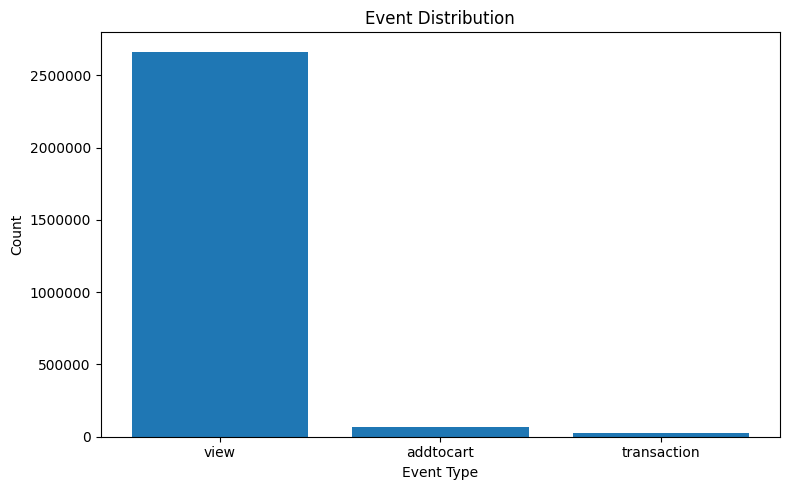

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\01_event_distribution.png


In [8]:
plt.figure(figsize=(8, 5))
plt.bar(event_distribution["event"].astype(str), event_distribution["event_count"])
plt.title("Event Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()

chart_path = CHART_DIR / "01_event_distribution.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"saved: {chart_path}")

## 7. User-Level Funnel Summary

이 단계에서는 이벤트 건수가 아니라 **사용자 기준**으로 퍼널을 계산한다.  
즉, 한 사용자가 같은 이벤트를 여러 번 발생시켜도 해당 단계에 도달한 사용자 1명으로 계산한다.

In [9]:
visitor_view = set(events.loc[events["event"] == "view", "visitorid"].unique())
visitor_cart = set(events.loc[events["event"] == "addtocart", "visitorid"].unique())
visitor_purchase = set(events.loc[events["event"] == "transaction", "visitorid"].unique())

n_view = len(visitor_view)
n_cart = len(visitor_cart)
n_purchase = len(visitor_purchase)

view_to_cart = n_cart / n_view if n_view else np.nan
cart_to_purchase = n_purchase / n_cart if n_cart else np.nan
view_to_purchase = n_purchase / n_view if n_view else np.nan

funnel_summary = pd.DataFrame({
    "funnel_stage": ["View", "Add to Cart", "Purchase"],
    "unique_visitors": [n_view, n_cart, n_purchase],
})

conversion_summary = pd.DataFrame({
    "conversion_step": ["View → Add to Cart", "Add to Cart → Purchase", "View → Purchase"],
    "conversion_rate": [view_to_cart, cart_to_purchase, view_to_purchase],
    "conversion_rate_pct": [view_to_cart * 100, cart_to_purchase * 100, view_to_purchase * 100],
})

display(funnel_summary)
display(conversion_summary)

save_table(funnel_summary, "01_events_user_level_funnel_summary.csv")
save_table(conversion_summary, "01_events_user_level_conversion_summary.csv")

,funnel_stage,unique_visitors
0,View,1404179
1,Add to Cart,37722
2,Purchase,11719


,conversion_step,conversion_rate,conversion_rate_pct
0,View → Add to Cart,0.0269,2.6864
1,Add to Cart → Purchase,0.3107,31.0668
2,View → Purchase,0.0083,0.8346


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_events_user_level_funnel_summary.csv
saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_events_user_level_conversion_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_events_user_level_conversion_summary.csv')

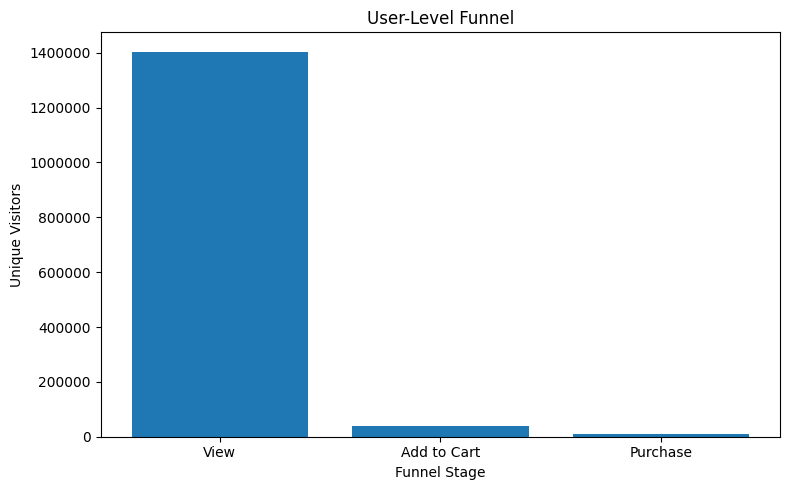

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\charts\01_user_level_funnel.png


In [10]:
plt.figure(figsize=(8, 5))
plt.bar(funnel_summary["funnel_stage"], funnel_summary["unique_visitors"])
plt.title("User-Level Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Visitors")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()

chart_path = CHART_DIR / "01_user_level_funnel.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"saved: {chart_path}")

## 8. Basic Entity Counts

분석 단위가 될 주요 객체 수를 확인한다.

In [11]:
entity_summary = pd.DataFrame([
    {"entity": "event_rows", "count": len(events)},
    {"entity": "unique_visitors", "count": events["visitorid"].nunique()},
    {"entity": "unique_items_in_events", "count": events["itemid"].nunique()},
    {"entity": "unique_transactions", "count": events["transactionid"].nunique(dropna=True)},
])

display(entity_summary)
save_table(entity_summary, "01_events_entity_summary.csv")

,entity,count
0,event_rows,2756101
1,unique_visitors,1407580
2,unique_items_in_events,235061
3,unique_transactions,17672


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_events_entity_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_events_entity_summary.csv')

## 9. Load and Audit `category_tree.csv`

카테고리 계층 구조 파일은 크기가 작으므로 전체를 로드한다.

In [12]:
category_tree = pd.read_csv(CATEGORY_TREE_PATH)

print("category_tree shape:", category_tree.shape)
display(category_tree.head())
display(category_tree.tail())

category_tree_audit = basic_df_audit(category_tree, "category_tree.csv")
display(category_tree_audit)
save_table(category_tree_audit, "01_category_tree_column_audit.csv")

category_tree_summary = pd.DataFrame([
    {"metric": "category_tree_rows", "value": len(category_tree)},
    {"metric": "unique_categoryid", "value": category_tree["categoryid"].nunique()},
    {"metric": "unique_parentid", "value": category_tree["parentid"].nunique(dropna=True)},
    {"metric": "root_categories", "value": category_tree["parentid"].isna().sum()},
])

display(category_tree_summary)
save_table(category_tree_summary, "01_category_tree_summary.csv")

category_tree shape: (1669, 2)


,categoryid,parentid
0,1016,213.0000
1,809,169.0000
2,570,9.0000
3,1691,885.0000
4,536,"1,691.0000"


,categoryid,parentid
1664,49,"1,125.0000"
1665,1112,630.0000
1666,1336,745.0000
1667,689,207.0000
1668,761,395.0000


,file,column,dtype,non_null_count,null_count,null_rate,unique_count
0,category_tree.csv,categoryid,int64,1669,0,0.0000,1669
1,category_tree.csv,parentid,float64,1644,25,0.0150,362


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_category_tree_column_audit.csv


,metric,value
0,category_tree_rows,1669
1,unique_categoryid,1669
2,unique_parentid,362
3,root_categories,25


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_category_tree_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_category_tree_summary.csv')

## 10. Chunk-Based Audit for Item Properties

`item_properties_part1.csv`와 `item_properties_part2.csv`는 매우 크기 때문에 chunk 단위로 점검한다.  
전체 파일을 무리하게 한 번에 합치지 않고, 필요한 요약값과 `categoryid` 정보만 추출한다.

In [13]:
ITEM_PROP_PATHS = [ITEM_PROP_1_PATH, ITEM_PROP_2_PATH]
ITEM_CHUNKSIZE = 2_000_000

item_property_summary_rows = []
property_count_frames = []
category_chunks = []

for path in ITEM_PROP_PATHS:
    print(f"processing: {path.name}")
    file_rows = 0
    unique_items = set()
    min_ts = None
    max_ts = None
    null_counts = None
    dtype_snapshot = None
    duplicate_sample_count = 0
    sample_rows = []
    
    for i, chunk in enumerate(pd.read_csv(path, chunksize=ITEM_CHUNKSIZE)):
        file_rows += len(chunk)
        unique_items.update(chunk["itemid"].dropna().unique().tolist())
        
        chunk_min = chunk["timestamp"].min()
        chunk_max = chunk["timestamp"].max()
        min_ts = chunk_min if min_ts is None else min(min_ts, chunk_min)
        max_ts = chunk_max if max_ts is None else max(max_ts, chunk_max)
        
        chunk_null_counts = chunk.isna().sum()
        null_counts = chunk_null_counts if null_counts is None else null_counts.add(chunk_null_counts, fill_value=0)
        
        if dtype_snapshot is None:
            dtype_snapshot = {col: str(dtype) for col, dtype in chunk.dtypes.items()}
        
        # Property frequency aggregation
        prop_counts = chunk["property"].value_counts().rename_axis("property").reset_index(name="count")
        prop_counts["source_file"] = path.name
        property_count_frames.append(prop_counts)
        
        # Extract categoryid only for item-category mapping.
        cat_chunk = chunk.loc[chunk["property"] == "categoryid", ["timestamp", "itemid", "value"]].copy()
        if not cat_chunk.empty:
            cat_chunk["source_file"] = path.name
            category_chunks.append(cat_chunk)
        
        # A small duplicated-row sample check for quick diagnostics.
        if i < 2:
            sample_rows.append(chunk.head(100_000))
        
        print(f"  chunk {i + 1} processed / cumulative rows: {file_rows:,}")
        del chunk
        gc.collect()
    
    if sample_rows:
        sample_df = pd.concat(sample_rows, ignore_index=True)
        duplicate_sample_count = int(sample_df.duplicated().sum())
        del sample_df, sample_rows
        gc.collect()
    
    item_property_summary_rows.append({
        "file": path.name,
        "row_count": file_rows,
        "unique_itemid": len(unique_items),
        "min_timestamp": min_ts,
        "max_timestamp": max_ts,
        "min_event_time": pd.to_datetime(min_ts, unit="ms"),
        "max_event_time": pd.to_datetime(max_ts, unit="ms"),
        "null_timestamp": int(null_counts.get("timestamp", 0)),
        "null_itemid": int(null_counts.get("itemid", 0)),
        "null_property": int(null_counts.get("property", 0)),
        "null_value": int(null_counts.get("value", 0)),
        "dtype_snapshot": json.dumps(dtype_snapshot, ensure_ascii=False),
        "duplicate_count_in_first_200k_sample": duplicate_sample_count,
    })
    
    del unique_items
    gc.collect()

item_property_summary = pd.DataFrame(item_property_summary_rows)
display(item_property_summary)
save_table(item_property_summary, "01_item_properties_file_summary.csv")

processing: item_properties_part1.csv
  chunk 1 processed / cumulative rows: 2,000,000
  chunk 2 processed / cumulative rows: 4,000,000
  chunk 3 processed / cumulative rows: 6,000,000
  chunk 4 processed / cumulative rows: 8,000,000
  chunk 5 processed / cumulative rows: 10,000,000
  chunk 6 processed / cumulative rows: 10,999,999
processing: item_properties_part2.csv
  chunk 1 processed / cumulative rows: 2,000,000
  chunk 2 processed / cumulative rows: 4,000,000
  chunk 3 processed / cumulative rows: 6,000,000
  chunk 4 processed / cumulative rows: 8,000,000
  chunk 5 processed / cumulative rows: 9,275,903


,file,row_count,unique_itemid,min_timestamp,max_timestamp,min_event_time,max_event_time,null_timestamp,null_itemid,null_property,null_value,dtype_snapshot,duplicate_count_in_first_200k_sample
0,item_properties_part1.csv,10999999,417053,1431226800000,1442113200000,2015-05-10 03:00:00,2015-09-13 03:00:00,0,0,0,0,"{""timestamp"": ""int64"", ""itemid"": ""int64"", ""pro...",0
1,item_properties_part2.csv,9275903,417053,1431226800000,1442113200000,2015-05-10 03:00:00,2015-09-13 03:00:00,0,0,0,0,"{""timestamp"": ""int64"", ""itemid"": ""int64"", ""pro...",0


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_item_properties_file_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_item_properties_file_summary.csv')

## 11. Item Property Frequency Summary

`property` 값별 등장 빈도를 확인한다.  
여기서 `categoryid`는 상품-카테고리 연결에 중요한 속성이다.

In [14]:
property_counts_all = pd.concat(property_count_frames, ignore_index=True)
property_counts_summary = (
    property_counts_all
    .groupby("property", as_index=False)["count"]
    .sum()
    .sort_values("count", ascending=False)
)

print("unique property count:", property_counts_summary["property"].nunique())
display(property_counts_summary.head(30))
save_table(property_counts_summary, "01_item_properties_property_counts.csv")

categoryid_count = property_counts_summary.loc[property_counts_summary["property"] == "categoryid", "count"]
categoryid_count = int(categoryid_count.iloc[0]) if len(categoryid_count) else 0
print("categoryid rows:", f"{categoryid_count:,}")

unique property count: 1104


,property,count
979,888,3000398
871,790,1790516
1102,available,1503639
1103,categoryid,788214
659,6,631471
309,283,597419
855,776,574220
746,678,481966
399,364,476486
221,202,448938


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_item_properties_property_counts.csv
categoryid rows: 788,214


## 12. Create Latest Item-Category Mapping

동일 item에 여러 시점의 `categoryid`가 있을 수 있으므로, 가장 최근 timestamp 기준으로 item별 대표 category를 만든다.  
이 결과는 `03_item_category_analysis.ipynb`에서 활용한다.

In [15]:
item_category_raw = pd.concat(category_chunks, ignore_index=True)
item_category_raw = item_category_raw.rename(columns={"value": "categoryid"})

item_category_raw["categoryid"] = pd.to_numeric(item_category_raw["categoryid"], errors="coerce")
item_category_raw = item_category_raw.dropna(subset=["categoryid"])
item_category_raw["categoryid"] = item_category_raw["categoryid"].astype("int64")
item_category_raw["property_time"] = pd.to_datetime(item_category_raw["timestamp"], unit="ms")

item_latest_category = (
    item_category_raw
    .sort_values(["itemid", "timestamp"])
    .drop_duplicates(subset=["itemid"], keep="last")
    [["itemid", "categoryid", "timestamp", "property_time", "source_file"]]
    .reset_index(drop=True)
)

print("item_category_raw shape:", item_category_raw.shape)
print("item_latest_category shape:", item_latest_category.shape)
display(item_latest_category.head())

save_parquet_or_csv(
    item_latest_category,
    parquet_name="item_latest_category.parquet",
    csv_name="item_latest_category.csv",
)

item_category_summary = pd.DataFrame([
    {"metric": "categoryid_property_rows", "value": len(item_category_raw)},
    {"metric": "unique_items_with_category", "value": item_latest_category["itemid"].nunique()},
    {"metric": "unique_categories_in_item_properties", "value": item_latest_category["categoryid"].nunique()},
])

display(item_category_summary)
save_table(item_category_summary, "01_item_category_mapping_summary.csv")

item_category_raw shape: (788214, 5)
item_latest_category shape: (417053, 5)


,itemid,categoryid,timestamp,property_time,source_file
0,0,209,1431226800000,2015-05-10 03:00:00,item_properties_part2.csv
1,1,1114,1431226800000,2015-05-10 03:00:00,item_properties_part1.csv
2,2,1305,1431226800000,2015-05-10 03:00:00,item_properties_part1.csv
3,3,1171,1433041200000,2015-05-31 03:00:00,item_properties_part1.csv
4,4,1038,1431831600000,2015-05-17 03:00:00,item_properties_part2.csv


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\data\processed\item_latest_category.csv
parquet save skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.


,metric,value
0,categoryid_property_rows,788214
1,unique_items_with_category,417053
2,unique_categories_in_item_properties,1180


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_item_category_mapping_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_item_category_mapping_summary.csv')

## 13. Event Item Coverage by Item Category Mapping

`events.csv`에 등장한 item 중 몇 개가 item property의 `categoryid`와 연결되는지 확인한다.  
이 비율이 충분히 높으면 카테고리 기반 분석을 진행할 수 있다.

In [16]:
event_item_ids = set(events["itemid"].unique())
category_item_ids = set(item_latest_category["itemid"].unique())
matched_item_ids = event_item_ids.intersection(category_item_ids)

coverage_summary = pd.DataFrame([
    {"metric": "unique_items_in_events", "value": len(event_item_ids)},
    {"metric": "unique_items_with_category", "value": len(category_item_ids)},
    {"metric": "matched_items", "value": len(matched_item_ids)},
    {"metric": "event_item_category_coverage_rate", "value": len(matched_item_ids) / len(event_item_ids)},
])

display(coverage_summary)
save_table(coverage_summary, "01_event_item_category_coverage.csv")

,metric,value
0,unique_items_in_events,"235,061.0000"
1,unique_items_with_category,"417,053.0000"
2,matched_items,"185,246.0000"
3,event_item_category_coverage_rate,0.7881


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_event_item_category_coverage.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_event_item_category_coverage.csv')

## 14. Save Cleaned Event Data for Later Notebooks

후속 노트북과 Streamlit에서 재사용할 수 있도록 최소 전처리된 이벤트 데이터를 저장한다.  
`data/processed/`는 GitHub에 올리지 않는 것을 권장한다.

In [17]:
events_clean = events.copy()

# transactionid는 결측이 많으므로 원본 float 형태를 유지한다.
# event_time, event_date, event_month는 후속 분석의 편의를 위해 포함한다.

save_parquet_or_csv(
    events_clean,
    parquet_name="events_clean.parquet",
    csv_name="events_clean.csv",
)

print("events_clean shape:", events_clean.shape)

saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\data\processed\events_clean.csv
parquet save skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
events_clean shape: (2756101, 8)


## 15. Integrated Raw Audit Summary

README와 기술서에 바로 활용할 수 있는 핵심 요약 테이블을 만든다.

In [18]:
raw_audit_summary = pd.DataFrame([
    {"section": "events", "metric": "Event rows", "value": len(events)},
    {"section": "events", "metric": "Unique visitors", "value": events["visitorid"].nunique()},
    {"section": "events", "metric": "Unique items in events", "value": events["itemid"].nunique()},
    {"section": "events", "metric": "Unique transactions", "value": events["transactionid"].nunique(dropna=True)},
    {"section": "events", "metric": "Event period start", "value": str(events["event_date"].min())},
    {"section": "events", "metric": "Event period end", "value": str(events["event_date"].max())},
    {"section": "item_properties", "metric": "Item property rows", "value": int(item_property_summary["row_count"].sum())},
    {"section": "item_properties", "metric": "Unique property types", "value": property_counts_summary["property"].nunique()},
    {"section": "item_properties", "metric": "categoryid rows", "value": categoryid_count},
    {"section": "item_properties", "metric": "Items with latest category", "value": item_latest_category["itemid"].nunique()},
    {"section": "category_tree", "metric": "Category tree rows", "value": len(category_tree)},
    {"section": "category_tree", "metric": "Root categories", "value": int(category_tree["parentid"].isna().sum())},
    {"section": "funnel", "metric": "View users", "value": n_view},
    {"section": "funnel", "metric": "Add-to-cart users", "value": n_cart},
    {"section": "funnel", "metric": "Purchase users", "value": n_purchase},
    {"section": "funnel", "metric": "View → Add to Cart", "value": f"{view_to_cart:.4%}"},
    {"section": "funnel", "metric": "Add to Cart → Purchase", "value": f"{cart_to_purchase:.4%}"},
    {"section": "funnel", "metric": "View → Purchase", "value": f"{view_to_purchase:.4%}"},
])

display(raw_audit_summary)
save_table(raw_audit_summary, "01_raw_audit_summary.csv")

,section,metric,value
0,events,Event rows,2756101
1,events,Unique visitors,1407580
2,events,Unique items in events,235061
3,events,Unique transactions,17672
4,events,Event period start,2015-05-03
5,events,Event period end,2015-09-18
6,item_properties,Item property rows,20275902
7,item_properties,Unique property types,1104
8,item_properties,categoryid rows,788214
9,item_properties,Items with latest category,417053


saved: c:\Users\USER\Desktop\ecommerce_ab_test_project\outputs\tables\01_raw_audit_summary.csv


WindowsPath('c:/Users/USER/Desktop/ecommerce_ab_test_project/outputs/tables/01_raw_audit_summary.csv')

## 16. Initial Interpretation

Raw data audit 결과를 바탕으로 다음과 같은 1차 해석을 정리한다.

1. 이 데이터는 실제 A/B 테스트 배정 정보가 포함된 실험 데이터가 아니라, 이커머스 행동 로그 데이터이다.
2. 따라서 본 프로젝트는 `행동로그 분석 → 전환 퍼널 진단 → A/B Test 설계 및 시뮬레이션` 구조로 진행하는 것이 적절하다.
3. 사용자 기준 전환 퍼널에서는 `view → addtocart` 단계의 이탈이 가장 크다.
4. 그러므로 A/B Test의 주요 실험 대상은 결제 페이지보다 상품 상세 페이지, 추천 영역, 장바구니 진입 CTA, 상품 탐색 경험이 더 적절하다.
5. item property의 `categoryid`를 활용하면 상품/카테고리 수준의 전환율 차이를 분석할 수 있다.

In [19]:
print("Raw data audit completed.")
print("Next notebook: 02_event_funnel_analysis.ipynb")

Raw data audit completed.
Next notebook: 02_event_funnel_analysis.ipynb
